<a href="https://colab.research.google.com/github/beasghoshdastidar/AI-LAB-/blob/main/waterjug.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

WATER JUG PROBLEM
Initial State: (0, 0)

Step 1: Fill B          → (0, 3)
Step 2: Pour B → A      → (3, 0)
Step 3: Fill B          → (3, 3)
Step 4: Pour B → A      → (4, 2)
Step 5: Goal: 2 litres  → (4, 2)

Minimum number of steps: 5


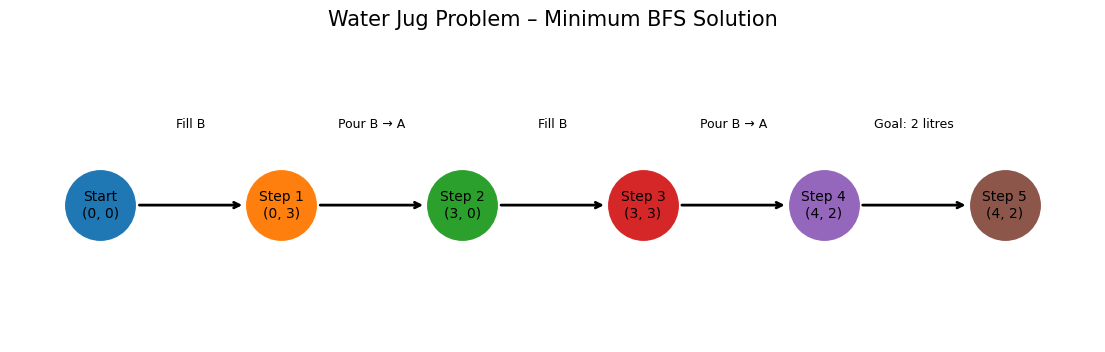

In [1]:
from collections import deque
import matplotlib.pyplot as plt

# Capacities
A = 4
B = 3

start = (0, 0)

# BFS
queue = deque([(start, [])])
visited = {start}

solution = None

while queue:
    state, path = queue.popleft()
    a, b = state

    # Goal
    if a == 2 or b == 2:
        solution = path + [(state, "Goal: 2 litres")]
        break

    next_states = []

    # Fill A
    next_states.append(((4, b), "Fill A"))

    # Fill B
    next_states.append(((a, 3), "Fill B"))

    # Empty A
    next_states.append(((0, b), "Empty A"))

    # Empty B
    next_states.append(((a, 0), "Empty B"))

    # Pour A -> B
    amount = min(a, 3 - b)
    next_states.append(
        ((a - amount, b + amount), "Pour A → B")
    )

    # Pour B -> A
    amount = min(b, 4 - a)
    next_states.append(
        ((a + amount, b - amount), "Pour B → A")
    )

    for new_state, action in next_states:
        if new_state not in visited:
            visited.add(new_state)
            queue.append(
                (new_state, path + [(new_state, action)])
            )


# -----------------------------
# Print solution
# -----------------------------

print("WATER JUG PROBLEM")
print("=" * 40)

print("Initial State: (0, 0)")
print()

for i, (state, action) in enumerate(solution, 1):
    print(f"Step {i}: {action:15} → {state}")

print()
print("Minimum number of steps:", len(solution))


# -----------------------------
# Visualize solution
# -----------------------------

states = [(0, 0)] + [state for state, action in solution]

plt.figure(figsize=(14, 4))

for i, state in enumerate(states):

    # Node
    plt.scatter(i, 0, s=2500)

    if i == 0:
        label = f"Start\n{state}"
    else:
        label = f"Step {i}\n{state}"

    plt.text(
        i, 0,
        label,
        ha='center',
        va='center',
        fontsize=10
    )

    # Arrow
    if i < len(states) - 1:
        plt.annotate(
            "",
            xy=(i + 0.8, 0),
            xytext=(i + 0.2, 0),
            arrowprops=dict(arrowstyle="->", linewidth=2)
        )

# Action labels
for i in range(1, len(solution) + 1):
    action = solution[i - 1][1]
    plt.text(
        i - 0.5, 0.45,
        action,
        ha='center',
        fontsize=9
    )

plt.title(
    "Water Jug Problem – Minimum BFS Solution",
    fontsize=15
)

plt.xlim(-0.5, len(states) - 0.5)
plt.ylim(-0.8, 1)
plt.axis('off')
plt.show()
